In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.optimize import minimize
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter


In [2]:
dfs = []
key = []
lab = []
subtitles = ['P113', 'OS-C', 'Buforin-2']

dfs.append(pd.read_csv('AMP_P113.csv').sample(frac = 1))
key.append([r'PolyA, ng/uL', r'P113, uM'])
lab.append([r'[RNA](ng/ul)', r'[AMP](uM)'])

dfs.append(pd.read_csv('AMP_Os-C.csv').sample(frac = 1))
key.append([r'PolyA, ng/uL', r'Os-C, uM'])
lab.append([r'[RNA](ng/ul)', r'[AMP](uM)'])

dfs.append(pd.read_csv('AMP_Buforin-2.csv').sample(frac = 1))
key.append([r'PolyA, ng/uL', r'Buforin-2, uM'])
lab.append([r'[RNA](ng/ul)', r'[AMP](uM)'])

# Store AMP names
variants = ["P113", "Os-C", "Buforin-2"]

In [3]:
# Definition of phase boundary points extraction function
def phase_boundary(xbins, ybins, P_field,
                   boundary_range=(0.2, 0.8),
                   smooth_sigma=1.0):
    if smooth_sigma > 0:
        P_smooth = gaussian_filter(P_field, sigma=smooth_sigma, mode='reflect')
    else:
        P_smooth = P_field.copy()

    XX, YY = np.meshgrid(xbins, ybins, indexing='xy')

    boundary_mask = (P_smooth >= boundary_range[0]) & (P_smooth <= boundary_range[1])
    bx = XX[boundary_mask]
    by = YY[boundary_mask]

    return bx, by


# ------------------------------------------------
# Build probability fields
# ------------------------------------------------
PS = []
RNAbins = np.linspace(100, 1500, 30)
AMPbins = np.linspace(0, 200, 30)
dRNA = RNAbins[1] - RNAbins[0]
dAMP = AMPbins[1] - AMPbins[0]

for i in range(3):
    _df = dfs[i]
    _x = _df[key[i][0]].values
    _y = _df[key[i][1]].values
    _feature = _df['feature'].values.astype(int)

    ps = np.zeros((len(RNAbins), len(AMPbins)))

    for j in range(len(RNAbins)):
        print(f'{i}-{j:02d}', end='\r')
        for k in range(len(AMPbins)):
            mask = (
                (RNAbins[j] - dRNA/2 < _x) & (_x < RNAbins[j] + dRNA/2) &
                (AMPbins[k] - dAMP/2 < _y) & (_y < AMPbins[k] + dAMP/2)
            )

            if np.any(mask):
                ps[j, k] = np.mean(_feature[mask])

    PS.append(ps)


# ------------------------------------------------
# Extract boundary points
# ------------------------------------------------
COORS = []

for i in range(3):
    ps = PS[i].T  # shape = (len(AMPbins), len(RNAbins))

    bx, by = phase_boundary(
        xbins=RNAbins,
        ybins=AMPbins,
        P_field=ps,
        boundary_range=(0.2, 0.8),
        smooth_sigma=1.0
    )

    COORS.append([bx, by])

In [4]:
# ----------------------------------
# Derivatives for error evaluation
# f(x) = s * x^{-b} * exp(c * x * exp(-p x))
# ----------------------------------
def df_ds(x, s, b, c, p):
    return x**(-b) * np.exp(c * x * np.exp(-p * x))

def df_db(x, s, b, c, p):
    f = s * x**(-b) * np.exp(c * x * np.exp(-p * x))
    return f * (-np.log(x))

def df_dc(x, s, b, c, p):
    f = s * x**(-b) * np.exp(c * x * np.exp(-p * x))
    return f * (x * np.exp(-p * x))

def df_dp(x, s, b, c, p):
    f = s * x**(-b) * np.exp(c * x * np.exp(-p * x))
    return f * (c * x * (-x) * np.exp(-p * x))

# ----------------------------------
# Global fit data prep + counting
# Convention:
#   - N_RAW[i]   = len(dfs[i])  (raw scan points)
#   - N_BOUND[i] = number of boundary points actually used in fitting (_x,_y) after mask
# ----------------------------------
_x_list, _y_list = [], []
N_RAW, N_BOUND = [], []

for i in range(3):
    # raw count (if dfs exists)
    if "dfs" in globals():
        N_RAW.append(len(dfs[i]))
    else:
        N_RAW.append(np.nan)

    # boundary data from COORS
    _x = np.asarray(COORS[i][0], dtype=float)
    _y = np.asarray(COORS[i][1], dtype=float)

    # same mask convention as your fitting/plots
    mask = (_y > 0) & (_y < 200) & (_x > 0) & (_x < 1600)
    _x = _x[mask]
    _y = _y[mask]

    _x_list.append(_x)
    _y_list.append(_y)

    N_BOUND.append(len(_x))

N_RAW = np.array(N_RAW)
N_BOUND = np.array(N_BOUND)

print("\nData counts (raw vs boundary-used):")
for i in range(3):
    print(f"{variants[i]}: N = {N_RAW[i]}, B = {N_BOUND[i]}")

# concatenate for global fit
x_all = np.concatenate(_x_list)
y_all = np.concatenate(_y_list)
idx_all = np.concatenate([np.full_like(_x_list[i], i, dtype=float) for i in range(3)])
X = np.vstack([x_all, idx_all])  # shape (2, N)

# ----------------------------------------------
# Global model: shared (s,b), per-slab (c_i,p_i)
# ----------------------------------------------
def model_global(X, s, b, c0, p0, c1, p1, c2, p2):
    x = X[0]
    idx = X[1].astype(int)

    c = np.zeros_like(x, dtype=float)
    p = np.zeros_like(x, dtype=float)

    c[idx == 0] = c0; p[idx == 0] = p0
    c[idx == 1] = c1; p[idx == 1] = p1
    c[idx == 2] = c2; p[idx == 2] = p2

    return s * x**(-b) * np.exp(c * x * np.exp(-p * x))

# initial guess + bounds
p0_global = [30.0, 1e-5, 0.01, 1e-4, 0.01, 1e-4, 0.01, 1e-4]
bounds_lower = [1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8, 1e-8]
bounds_upper = [np.inf,  10.0, np.inf, np.inf, np.inf, np.inf, np.inf, np.inf]

popt_g, pcov_g = curve_fit( model_global, X, y_all, p0=p0_global,
                          bounds=(bounds_lower, bounds_upper), maxfev=60000 )

perr_g = np.sqrt(np.diag(pcov_g))
s_fit_g, b_fit_g = popt_g[0], popt_g[1]
ds_g, db_g = perr_g[0], perr_g[1]

print("\n================ Fitting Results ================")
print("s_global = %.3g ± %.3g" % (s_fit_g, ds_g))
print("b_global = %.3g ± %.3g" % (b_fit_g, db_g))
for i in range(3):
    print(f"{variants[i]}: c = {popt_g[2+2*i]:.6g}, p = {popt_g[3+2*i]:.6g}")




Data counts (raw vs boundary-used):
P113: N = 246955, B = 193
Os-C: N = 84398, B = 132
Buforin-2: N = 167030, B = 186

================ Fitting Results ================
s_global = 5.21e+03 ± 4.66e+03
b_global = 0.941 ± 0.202
P113: c = 0.00204313, p = 2.95709e-05
Os-C: c = 0.00379189, p = 0.000409983
Buforin-2: c = 0.00468931, p = 0.000492158


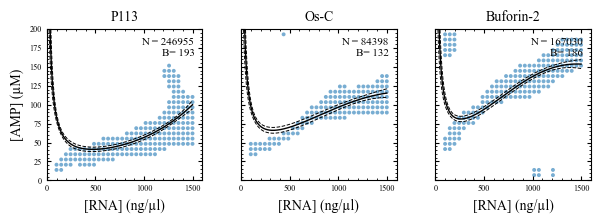

In [5]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times"],
    "font.size": 10,
    "axes.labelsize":10,
    "axes.titlesize": 10,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.top": True,
    "ytick.right": True,
    "legend.fontsize": 6,
})

# ------------------------------------
# Plot boundary points + ±1σ envelope 
# ------------------------------------
xx = np.linspace(0.01, 1500, 8000)

fig, axes = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(6.8, 2.1))

for i, ax in enumerate(axes):
    _x = _x_list[i]
    _y = _y_list[i]

    # plot boundary points
    ax.scatter(_x, _y, s=8, edgecolor='none', color='tab:blue', alpha=0.6)

    # parameters for this slab
    s = popt_g[0]
    b = popt_g[1]
    c = popt_g[2 + 2*i]
    p = popt_g[3 + 2*i]

    # mean curve
    y_fit = s * xx**(-b) * np.exp(c * xx * np.exp(-p * xx))
    ax.plot(xx, y_fit, color="black", lw=1.0, zorder=6)

    # envelope using full 8D covariance
    dsd = df_ds(xx, s, b, c, p)
    dbd = df_db(xx, s, b, c, p)
    dcd = df_dc(xx, s, b, c, p)
    dpd = df_dp(xx, s, b, c, p)

    G = np.zeros((len(xx), 8), dtype=float)  # [s,b,c0,p0,c1,p1,c2,p2]
    G[:, 0] = dsd
    G[:, 1] = dbd
    G[:, 2 + 2*i] = dcd
    G[:, 3 + 2*i] = dpd

    var = np.einsum("ni,ij,nj->n", G, pcov_g, G)
    var = np.maximum(var, 0.0)
    sigma = np.sqrt(var)

    ax.plot(xx, y_fit + sigma, color="black", ls="--", lw=0.7, zorder=6)
    ax.plot(xx, np.clip(y_fit - sigma, 0, None), color="black", ls="--", lw=0.7, zorder=6)

    # styling
    ax.set_title(f"{variants[i]}")
    ax.set_xlabel(r"[RNA] (ng/µl)")
    if i == 0:
        ax.set_ylabel(r"[AMP] (µM)")
    ax.set_xlim(0, 1600)
    ax.set_ylim(0, 200)
    ax.minorticks_on()

    # data number counts
    ax.text(
        0.95, 0.95,
        f"N = {N_RAW[i]}\nB= {N_BOUND[i]}",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8
    )

plt.subplots_adjust(left=0.08, right=0.88, top=0.90, bottom=0.18, wspace=0.25)

plt.show()


In [6]:

idx = np.array([2 + 2*i for i in range(3)])

c_vals = popt_g[idx]
p_vals = popt_g[idx + 1]

c_err = np.sqrt(pcov_g[idx, idx])
p_err = np.sqrt(pcov_g[idx + 1, idx + 1])

ratio_vals = p_vals / c_vals
ratio_err = ratio_vals * np.sqrt((p_err / p_vals)**2 + (c_err / c_vals)**2)


# Calculate physical quantities


# Three-body repulsion χ^(3)
repulsion_vals = c_vals/(1.8*0.01*10*1e4*0.01*0.47*1e-9)
repulsion_err = c_err/(1.8*0.01*10*1e4*0.01*0.47*1e-9)

# Competition Δχ
dchi_vals = p_vals/(1.8*0.01*1e4*1e4*0.47*1e-9)
dchi_err = p_err/(1.8*0.01*1e4*1e4*0.47*1e-9)

# AMP-RNA dissociation constant K_D (μM)
kd_vals = ratio_vals * ( (2*0.01)/(1.8*0.01*1e4) ) * 1e6
kd_err = ratio_err * ( (2*0.01)/(1.8*0.01*1e4) ) * 1e6


print("\n================== Calculated Physical Quantities =================\n")
for name, r, r_err, d, d_err, k, k_err in zip( variants, repulsion_vals, repulsion_err,
                                  dchi_vals, dchi_err, kd_vals, kd_err ):
    print(
        f"{name}: χ_3 = {r:.0f}±{r_err:.0f}, "
        f"Δχ = {d:.3f}±{d_err:.3f}, "
        f"K_D = {k:.3f}±{k_err:.3f} μM"
    )
    
    print()


================== Calculated Physical Quantities =================

P113: χ_3 = 241505±97686, Δχ = 0.035±0.178, K_D = 1.608±8.212 μM

Os-C: χ_3 = 448214±109540, Δχ = 0.485±0.066, K_D = 12.013±3.355 μM

Buforin-2: χ_3 = 554292±111005, Δχ = 0.582±0.040, K_D = 11.661±2.469 μM



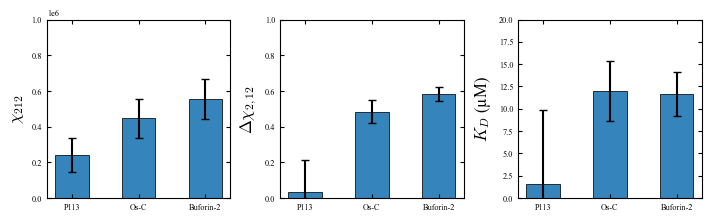

In [7]:
# Plot the inferred physical quantities
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "cm",
    "font.size": 10,
    "axes.linewidth": 0.8,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "ytick.minor.size": 1.5,
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "errorbar.capsize": 2.5,
})

# --------------------------------------------------------------
# Three subplots: χ^(3), Δχ and K_D
# --------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(7.0, 2.1), constrained_layout=True)
bar_width = 0.5

# Colors for bars
colors = ['tab:blue','tab:blue','tab:blue']

# Three-body parameter χ^(3)
axes[0].bar(variants, repulsion_vals, yerr=repulsion_err, width=bar_width, color=colors,
            edgecolor='k', alpha=0.9, linewidth=0.6, capsize=3)
axes[0].set_ylabel(r"$\chi_{212}$")
axes[0].set_ylim(0, 1e6)
#axes[0].set_yscale('log')
#axes[0].text(0.05, 0.93, transform=axes[0].transAxes, fontweight='bold')


# Comptition Δχ
axes[1].bar(variants, dchi_vals, yerr=dchi_err, width=bar_width, color=colors,
            edgecolor='k', alpha=0.9, linewidth=0.6, capsize=3)
axes[1].set_ylabel(r"$\Delta\chi_{2,12}$")
axes[1].set_ylim(0, 1.0)
#axes[1].text(0.05, 0.93, transform=axes[1].transAxes, fontweight='bold')

# Dissociation constant K_D
axes[2].bar(variants, kd_vals, yerr=kd_err, width=bar_width, color=colors,
            edgecolor='k', alpha=0.9, linewidth=0.6, capsize=3)
axes[2].set_ylabel(r"$K_D$ (µM)")
axes[2].set_ylim(0, 20)
#axes[2].text(0.05, 0.93, transform=axes[2].transAxes, fontweight='bold')

# Axis
for ax in axes:
    ax.tick_params(which='both', direction='in')
    ax.spines['top'].set_visible(True)
    ax.spines['right'].set_visible(True)

plt.show()


In [8]:
def panel_label(ax, text, x=-0.20, y=1.10, fontsize=11, bold=False):
    ax.text(
        x, y, text,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=fontsize,
        fontweight="bold" if bold else "normal",
        clip_on=False
    )


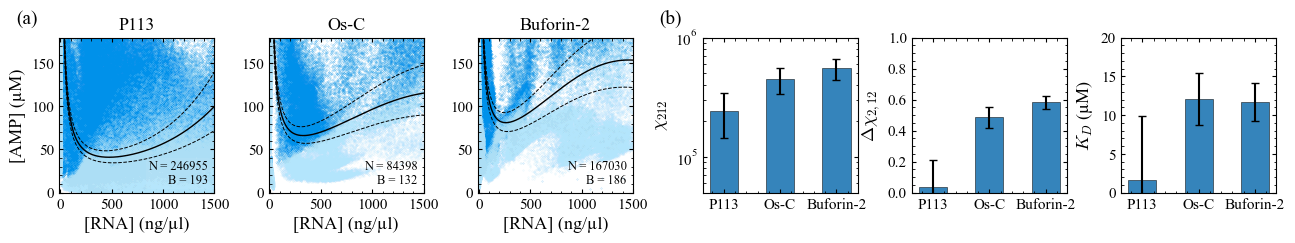

In [9]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "Nimbus Roman", "STIXGeneral"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "axes.linewidth": 0.8,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.frameon": False,
    "errorbar.capsize": 2.5,
})


# ==========================================================
# Defaults
# ==========================================================
names_top = ["P113", "Os-C", "Buforin-2"]   # for titles on top row
xlim_top = (-10, 1500)
ylim_top = (0, 180)
ylim_chi3 = (0, 5e5)
ylim_dchi = (0, 1.0)
ylim_kd   = (0, 40)



# ==========================================================
# Layout Control: (a) left 3, (b) right 3
# ==========================================================

AX = 2.0                 # square panel width (match reference AX_A or AX_R)
WSPACE_INNER = 0.35      # match WSPACE_A (or WSPACE_R if desired)
GUTTER = 0.90            # real physical gutter between (a) and (b)

gap = WSPACE_INNER * AX

# total width of 3 panels
W_block = 3 * AX + 2 * gap

FIG_W = W_block + GUTTER + W_block
FIG_H = AX + 1.0   # small top/bottom margins

fig = plt.figure(figsize=(FIG_W, FIG_H))

# 3 blocks: left | gutter | right 
gs = fig.add_gridspec( nrows=1, ncols=3, width_ratios=[W_block, GUTTER, W_block], wspace=0.0 )
                       # IMPORTANT: no extra automatic spacing

# Left 3 panels
gs_left = gs[0].subgridspec(1, 3, wspace=WSPACE_INNER)
ax_top = [fig.add_subplot(gs_left[0, j]) for j in range(3)]

# Right 3 panels
gs_right = gs[2].subgridspec(1, 3, wspace=WSPACE_INNER)
ax_bot = [fig.add_subplot(gs_right[0, j]) for j in range(3)]


for ax in ax_top + ax_bot:
    ax.set_box_aspect(1)



# ==========================================================
# Fig. 5(a): phase boundary + envelope (GLOBAL shared s,b; independent c,p)
# ==========================================================

xx = np.linspace(0.01, 1500, 8000)

for i in range(3):
    # parameters for this variant (shared s,b)
    s = popt_g[0]
    b = popt_g[1]
    c = popt_g[2 + 2*i]
    p = popt_g[3 + 2*i]

    ds = np.sqrt(pcov_g[0, 0])
    db = np.sqrt(pcov_g[1, 1])
    dc = np.sqrt(pcov_g[2 + 2*i, 2 + 2*i])
    dp = np.sqrt(pcov_g[3 + 2*i, 3 + 2*i])

    # global-fit mean curve
    y_fit_avg = s * xx**(-b) * np.exp(c * xx * np.exp(-p * xx))

    # envelope by ±0.1σ in (b,c,p) (keep your original definition)
    combos = np.array(np.meshgrid(*[[-1, 1]] * 3)).T.reshape(-1, 3)
    y_iter = np.array([
        (s * xx**(-(b + 0.1*sgn[0]*db)) *
         np.exp((c + 0.1*sgn[1]*dc) * xx * np.exp(-(p + 0.1*sgn[2]*dp) * xx)))
        for sgn in combos
    ])
    y_fit_max = np.max(y_iter, axis=0)
    y_fit_min = np.min(y_iter, axis=0)

    df = dfs[i]
    mask_true  = df["feature"].astype(bool)
    mask_false = ~mask_true

    ax = ax_top[i]

    # raw data
    ax.scatter(df.loc[mask_true, key[i][0]],
               df.loc[mask_true, key[i][1]],
               s=0.04, color="#0091ea", alpha=0.5, rasterized=True)

    ax.scatter(df.loc[mask_false, key[i][0]],
               df.loc[mask_false, key[i][1]],
               s=0.04, color="#b3e5fc", alpha=0.5, rasterized=True)

    # fit + dashed envelope
    ax.plot(xx, y_fit_avg, color="black", lw=1.0, zorder=6)
    ax.plot(xx, y_fit_max, color="black", ls="--", lw=0.7, zorder=6)
    ax.plot(xx, y_fit_min, color="black", ls="--", lw=0.7, zorder=6)

    ax.set_title(f"{names_top[i]}")
    ax.set_xlabel(r"[RNA] (ng/µl)")
    if i == 0:
        ax.set_ylabel(r"[AMP] (µM)")

    # counts in upper-right (raw and boundary-used)
    ax.text(
        0.96, 0.04,
        f"N = {N_RAW[i]}\nB = {N_BOUND[i]}",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.05,
            boxstyle="round,pad=0.2"
        )
    )

    ax.set_xlim(*xlim_top)
    ax.set_ylim(*ylim_top)
    ax.set_xticks([0, 500, 1000, 1500])
    ax.minorticks_on()

panel_label(ax_top[0], "(a)", x=-0.28, y=1.18, fontsize=14, bold=False)




# ==========================================================
# Fig. 5(b): bar charts
# ==========================================================
bar_width = 0.50
colors = ["tab:blue"] * len(variants)

ax = ax_bot[0]
ax.bar(variants, repulsion_vals, yerr=repulsion_err, width=bar_width,
       color=colors, edgecolor="k", alpha=0.9, linewidth=0.4, capsize=3)
ax.set_ylabel(r"$\chi_{212}$")
ax.set_ylim(5*1e4, 1e6)
ax.set_yscale('log')
ax.tick_params(axis='x', labelsize=11)
ax.minorticks_on()

ax = ax_bot[1]
ax.bar(variants, dchi_vals, yerr=dchi_err, width=bar_width,
       color=colors, edgecolor="k", alpha=0.9, linewidth=0.4, capsize=3)
ax.set_ylabel(r"$\Delta\chi_{2,12}$")
ax.set_ylim(0, 1)
ax.tick_params(axis='x', labelsize=11)
ax.minorticks_on()

ax = ax_bot[2]
ax.bar(variants, kd_vals, yerr=kd_err, width=bar_width,
       color=colors, edgecolor="k", alpha=0.9, linewidth=0.4, capsize=3)
ax.set_ylabel(r"$K_D$ (µM)")
ax.set_ylim(0, 20)
ax.tick_params(axis='x', labelsize=11)
ax.minorticks_on()

panel_label(ax_bot[0], "(b)", x=-0.28, y=1.18, fontsize=14, bold=False)


for ax in ax_top + ax_bot:
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)


# ==========================================================
# Export
# ==========================================================
#fig.savefig("Figure_5.pdf", bbox_inches="tight")
#fig.savefig("Figure_5.png", dpi=600)
plt.show()